In [1]:
library(ggplot2)
library(data.table)

Warning message:
“程辑包‘ggplot2’是用R版本4.1.3 来建造的”


In [2]:
geno = read.table('./input/HLA_classic_inter/SNP.txt',header = TRUE)

In [3]:
eg = 'HLA-DRB1'
es = 'HLA_DRB1_3.01'
ed_all = data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')){
    exp = read.table(paste0('./input/HLA_classic_inter/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],geno[es,re])))
    colnames(ed) = c('gene','geno')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }

In [4]:
ed_all[is.na(ed_all)] = 0
ed_all$ct = factor(ed_all$ct,levels = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma'))

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


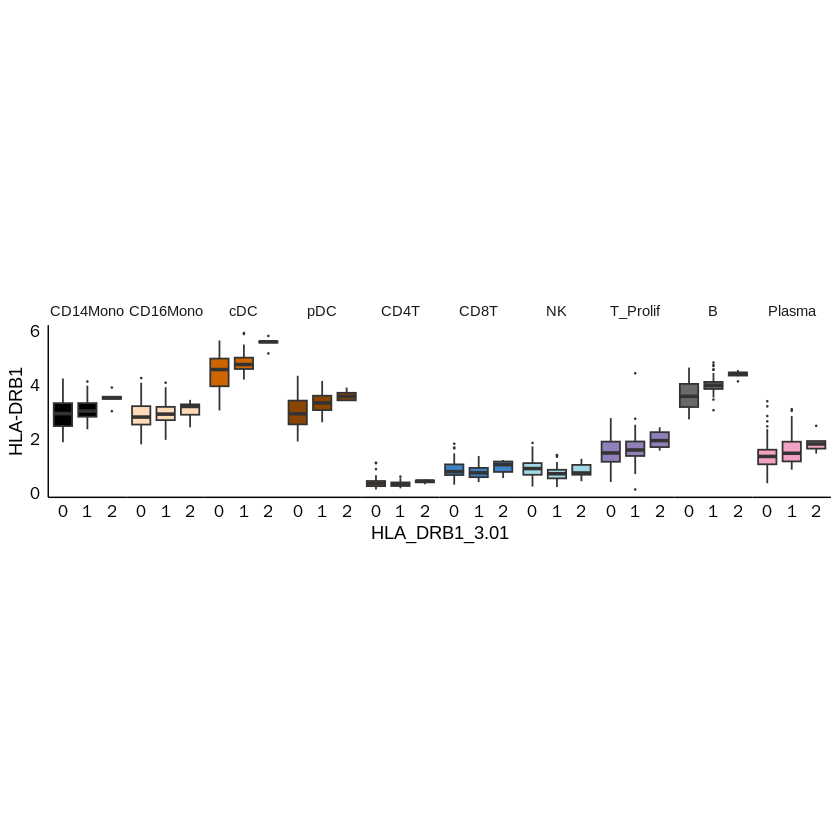

In [5]:
p <- ggplot(ed_all, aes(x = geno, y = gene,fill = ct)) +
  geom_boxplot(outlier.size = 0.1) +
  labs(
    x = es,
    y = eg
  ) +scale_fill_manual(values = c('black','#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A'))+
 facet_wrap(~ct, scales = 'free_x', nrow = 1)+theme_minimal()+
theme(aspect.ratio = 2.2,
        axis.line = element_line(color = "black",size = 0.4),
        axis.text.y = element_text(color="black",size=10),
        axis.text.x = element_text(margin = margin(t = 2),color="black",size=10),
        legend.position = "none",
        panel.spacing = unit(0,"lines"),
     panel.grid = element_blank())#+ylim(c(0,1))
p

In [6]:
eg = 'HLA-DRB1'
es = 'HLA_DRB1_9.01'
ed_all = data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')){
    exp = read.table(paste0('./input/HLA_classic_inter/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],geno[es,re])))
    colnames(ed) = c('gene','geno')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }


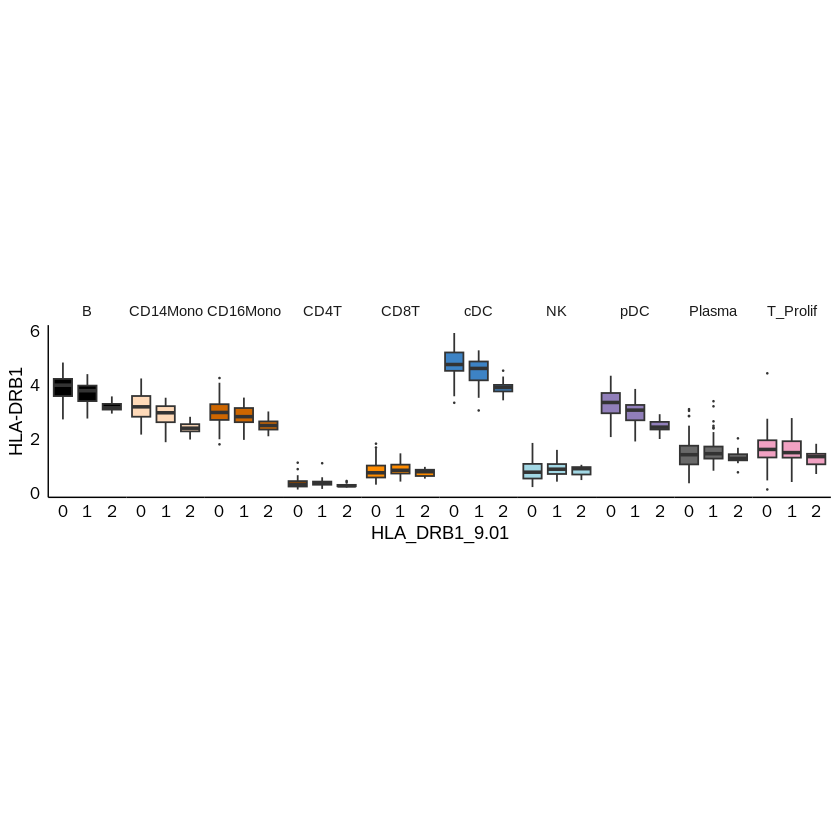

In [7]:
p1 <- ggplot(ed_all, aes(x = geno, y = gene,fill = ct)) +
  geom_boxplot(outlier.size = 0.1) +
  labs(
    x = es,
    y = eg
  ) +scale_fill_manual(values = c('black','#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A'))+
 facet_wrap(~ct, scales = 'free_x', nrow = 1)+theme_minimal()+
theme(aspect.ratio = 2.2,
        axis.line = element_line(color = "black",size = 0.4),
        axis.text.y = element_text(color="black",size=10),
        axis.text.x = element_text(margin = margin(t = 2),color="black",size=10),
        legend.position = "none",
        panel.spacing = unit(0,"lines"),
     panel.grid = element_blank())#+ylim(c(0,1))
p1

In [8]:
df_all_0= data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')) {
    df =  data.frame(fread(paste0("./res/HLA_classic_All/",ct,"_cis_fdr005.csv")))
    df$ct = ct
    df_all_0 = rbind(df_all_0,df)
    }
df_all_0$sign = paste0(df_all_0$gene,'-',df_all_0$snps,'-',df_all_0$ct)

In [9]:
re1 = c('HLA-DRB1','HLA-DQA1','HLA-DQB1','HLA-B','HLA-B')
re2 = c('HLA_DRB1_3.01','HLA_DRB1_3.01','HLA_DRB1_3.01','HLA_C_3.02','HLA_B_58.01')
df_all  =data.frame()
for (i in seq(1,length(re1))){
    eg = re1[i]
    es = re2[i]
    for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')){
        exp = read.table(paste0('./input/HLA_classic_inter/',ct,'_GE.txt'))
        geno = read.table(paste0('./input/HLA_classic_inter','/SNP.txt'),header = TRUE)
        covar = read.table(paste0('./input/HLA_classic_inter','/Covariates.txt'))
        re = intersect(colnames(exp),colnames(geno))
        covar = covar[,re]  
        ed = data.frame(t(rbind(exp[eg,re],geno[es,re])))
        colnames(ed) = c('gene','geno')
        ed$geno = as.numeric(ed$geno)
        ed = cbind(ed,t(covar))
        mod = lm(as.formula(paste('gene', ' ~ ', 'geno','+',paste(rownames(covar), collapse = "+"), sep = "")), data = ed)
        df_temp = data.frame(snps = es, 
               gene = eg,
               beta = summary(mod)$coefficients['geno', 'Estimate'], 
               stderr = summary(mod)$coefficients['geno', 'Std. Error'],
               t.val = summary(mod)$coefficients['geno', 't value'],
               p.val = summary(mod)$coefficients['geno', 'Pr(>|t|)'],
          lower = confint(mod)['geno',1],
          upper = confint(mod)['geno',2],
          ct = ct)
        df_all = rbind(df_all,df_temp)
        }
    }

In [10]:
df_all$ct = factor(df_all$ct,levels = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma'))
df_all$eqtl = paste0(df_all$gene,'-',df_all$snps)

In [11]:
df_all$sign = paste0(df_all$eqtl,'-',df_all$ct)
df_all$size  = 2
df_all[df_all$sign %in% df_all_0$sign,'size'] = 3
df_all$sig  = 'non-sig'
df_all[df_all$sign %in% df_all_0$sign,'sig'] = 'sig'
df_all$dis ='HLA'
df_all$eqtl = factor(df_all$eqtl,levels = unique(df_all$eqtl))

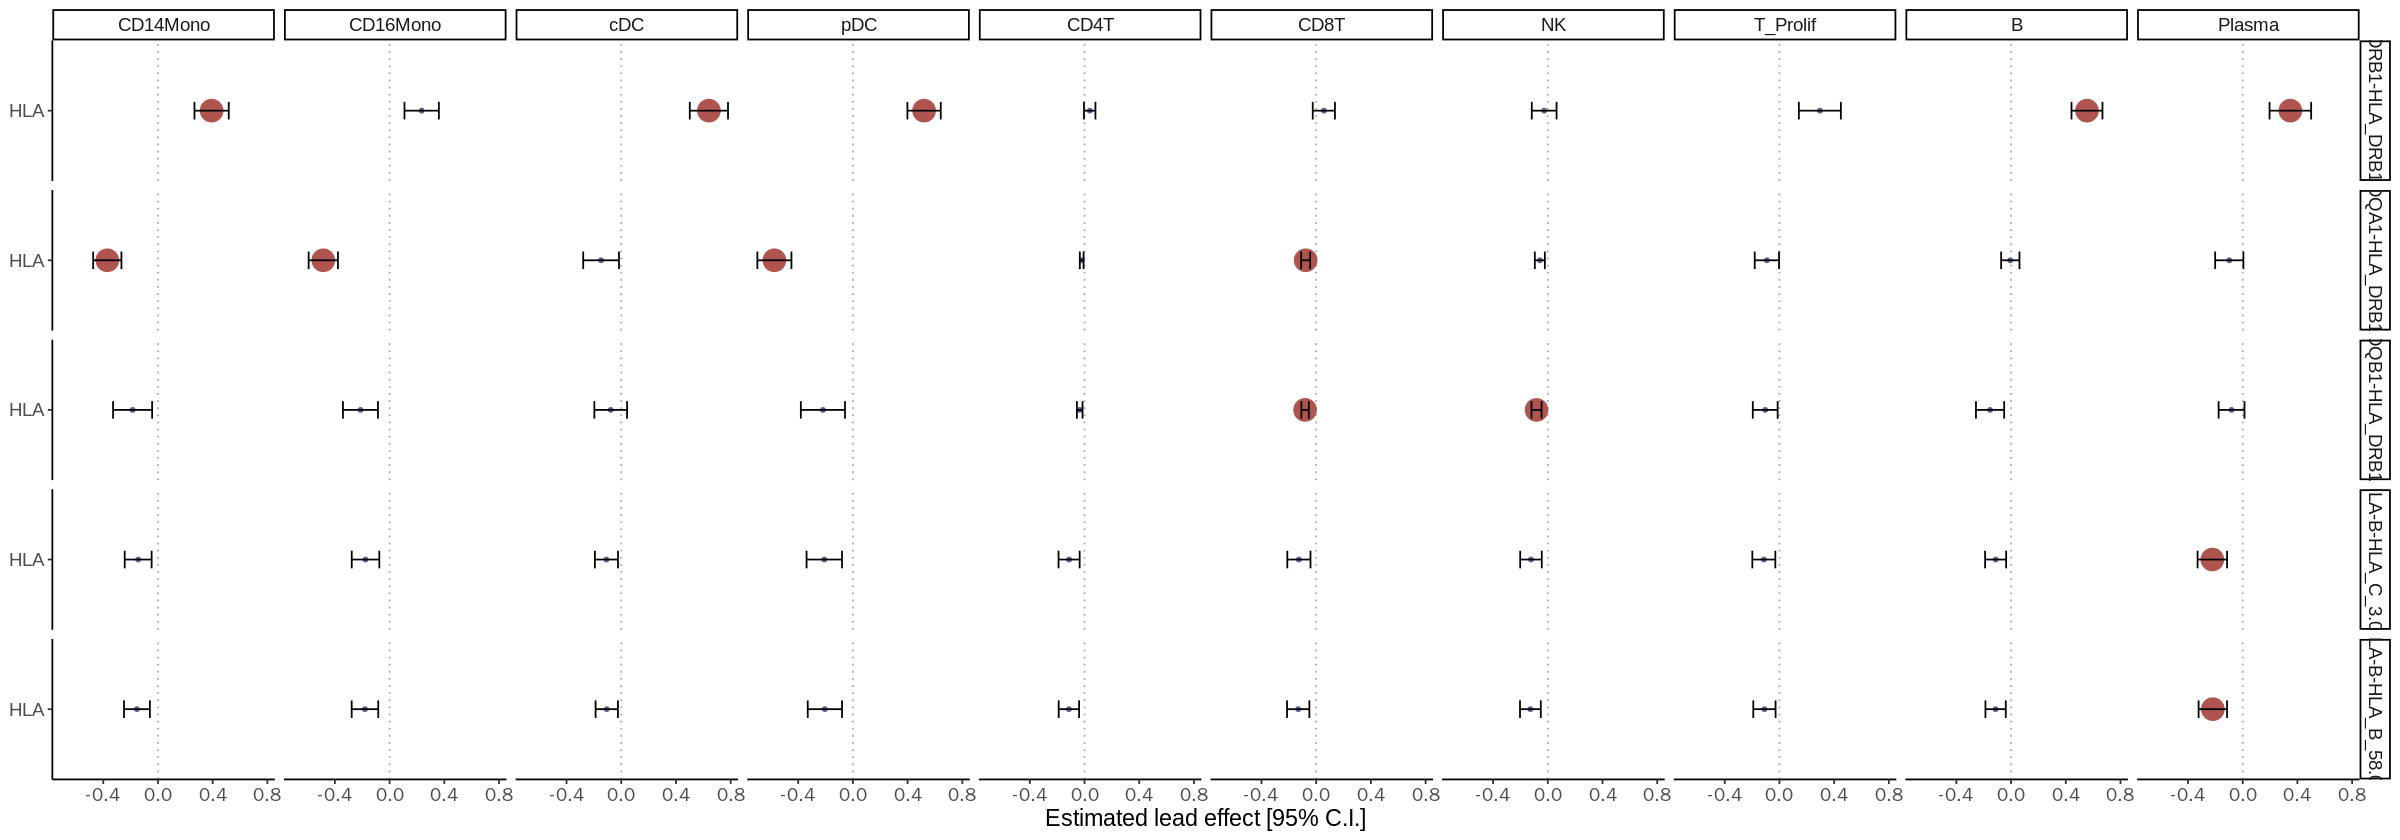

In [12]:
options(repr.plot.width=20,rpr.plot.height=5)
fp = ggplot(data=df_all) +
        geom_hline(yintercept=0, lty=3, col = 'darkgrey') +  
        geom_point( aes(x=dis, y=beta, col = sig,size = size)) + 
        geom_errorbar(aes(x=dis, y=beta, col = sign, ymin = upper, ymax = lower), col = 'black', width = 0.15) + 
        theme_classic() + 
        coord_flip() +
        xlab(NULL) + ylab("Estimated lead effect [95% C.I.]") + scale_color_manual(values = c('#5a6899','#b0544f')) +
        theme(legend.position = 'none') + 
        facet_grid(factor(eqtl) ~ factor(ct)) + 
        theme(text = element_text(size=14),
             ) 
fp